In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, f1_score
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE, BorderlineSMOTE
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.manifold import TSNE
import umap
import trimap
import pacmap


In [2]:
file_path = 'soybean-large.data'
column_names = ['class'] + [f'attr_{i}' for i in range(35)]
data = pd.read_csv(file_path, header=None, names=column_names, na_values='?')

class_counts = data['class'].value_counts()
rare_classes = class_counts[class_counts < 2].index

if not rare_classes.empty:
    print(f"Обнаружены слишком редкие классы: {list(rare_classes)}")
    print(f"Удаление {len(rare_classes)} объекта(ов) для корректной стратификации...")
    data = data[~data['class'].isin(rare_classes)].reset_index(drop=True)

Обнаружены слишком редкие классы: ['2-4-d-injury']
Удаление 1 объекта(ов) для корректной стратификации...


In [3]:
X = data.drop('class', axis=1)
y = data['class']

imputer = SimpleImputer(strategy='most_frequent')
X_imputed = imputer.fit_transform(X)

le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Размер обучающей выборки (X): {X_train_scaled.shape}")
print(f"Размер тестовой выборки (X): {X_test_scaled.shape}")

# Посмотрим на дисбаланс классов в обучающей выборке
print("\nДисбаланс классов (до балансировки):")
print(pd.Series(y_train).value_counts().sort_index())

Размер обучающей выборки (X): (214, 35)
Размер тестовой выборки (X): (92, 35)

Дисбаланс классов (до балансировки):
0     28
1     14
2      7
3      7
4     28
5     14
6      7
7      4
8      4
9      7
10     7
11    28
12     3
13     7
14    28
15     7
16     7
17     7
Name: count, dtype: int64


In [6]:
results = {}

def train_and_evaluate(model, X_train, y_train, X_test, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    score = f1_score(y_test, y_pred, average='weighted')
    results[model_name] = score
    print(f"--- {model_name} ---")
    print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))
    print(f"Weighted F1-Score: {score:.4f}\n")


In [7]:
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

In [8]:
print("===== РЕЗУЛЬТАТЫ ДО БАЛАНСИРОВКИ =====")
train_and_evaluate(svm, X_train_scaled, y_train, X_test_scaled, y_test, 'SVM (Baseline)')
train_and_evaluate(knn, X_train_scaled, y_train, X_test_scaled, y_test, 'k-NN (Baseline)')
train_and_evaluate(rf, X_train_scaled, y_train, X_test_scaled, y_test, 'RF (Baseline)')

===== РЕЗУЛЬТАТЫ ДО БАЛАНСИРОВКИ =====
--- SVM (Baseline) ---
                             precision    recall  f1-score   support

        alternarialeaf-spot       0.75      1.00      0.86        12
                anthracnose       0.86      1.00      0.92         6
           bacterial-blight       1.00      0.67      0.80         3
          bacterial-pustule       1.00      1.00      1.00         3
                 brown-spot       0.80      1.00      0.89        12
             brown-stem-rot       1.00      1.00      1.00         6
               charcoal-rot       1.00      1.00      1.00         3
              cyst-nematode       1.00      1.00      1.00         2
diaporthe-pod-&-stem-blight       1.00      1.00      1.00         2
      diaporthe-stem-canker       1.00      1.00      1.00         3
               downy-mildew       1.00      1.00      1.00         3
         frog-eye-leaf-spot       1.00      0.75      0.86        12
           herbicide-injury       1.00  

In [9]:
# 1. SMOTE [cite: 5]
smote = SMOTE(random_state=42, k_neighbors=1) # k_neighbors=1, т.к. есть классы с 2-мя объектами
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
print("Размеры после SMOTE:", X_train_smote.shape)

# 2. Borderline-SMOTE 1 [cite: 9]
bsmote1 = BorderlineSMOTE(random_state=42, kind='borderline-1', k_neighbors=1, m_neighbors=2)
X_train_bsmote1, y_train_bsmote1 = bsmote1.fit_resample(X_train_scaled, y_train)
print("Размеры после Borderline-SMOTE 1:", X_train_bsmote1.shape)

# 3. Borderline-SMOTE 2 [cite: 13]
bsmote2 = BorderlineSMOTE(random_state=42, kind='borderline-2', k_neighbors=1, m_neighbors=2)
X_train_bsmote2, y_train_bsmote2 = bsmote2.fit_resample(X_train_scaled, y_train)
print("Размеры после Borderline-SMOTE 2:", X_train_bsmote2.shape)

# Словарь со сбалансированными наборами
balanced_datasets = {
    "SMOTE": (X_train_smote, y_train_smote),
    "Borderline-1": (X_train_bsmote1, y_train_bsmote1),
    "Borderline-2": (X_train_bsmote2, y_train_bsmote2)
}

Размеры после SMOTE: (504, 35)
Размеры после Borderline-SMOTE 1: (312, 35)
Размеры после Borderline-SMOTE 2: (312, 35)


In [10]:
print("\n===== РЕЗУЛЬТАТЫ ПОСЛЕ БАЛАНСИРОВКИ =====")

for method_name, (X_bal, y_bal) in balanced_datasets.items():
    print(f"\n--- Используется метод: {method_name} ---")

    # Сброс моделей
    svm = SVC(kernel='rbf', random_state=42)
    knn = KNeighborsClassifier(n_neighbors=5)
    rf = RandomForestClassifier(n_estimators=100, random_state=42)

    # Обучение и оценка
    train_and_evaluate(svm, X_bal, y_bal, X_test_scaled, y_test, f'SVM ({method_name})')
    train_and_evaluate(knn, X_bal, y_bal, X_test_scaled, y_test, f'k-NN ({method_name})')
    train_and_evaluate(rf, X_bal, y_bal, X_test_scaled, y_test, f'RF ({method_name})')


===== РЕЗУЛЬТАТЫ ПОСЛЕ БАЛАНСИРОВКИ =====

--- Используется метод: SMOTE ---
--- SVM (SMOTE) ---
                             precision    recall  f1-score   support

        alternarialeaf-spot       0.75      1.00      0.86        12
                anthracnose       1.00      1.00      1.00         6
           bacterial-blight       1.00      1.00      1.00         3
          bacterial-pustule       1.00      1.00      1.00         3
                 brown-spot       0.92      1.00      0.96        12
             brown-stem-rot       1.00      1.00      1.00         6
               charcoal-rot       1.00      1.00      1.00         3
              cyst-nematode       1.00      1.00      1.00         2
diaporthe-pod-&-stem-blight       1.00      1.00      1.00         2
      diaporthe-stem-canker       1.00      1.00      1.00         3
               downy-mildew       1.00      1.00      1.00         3
         frog-eye-leaf-spot       1.00      0.75      0.86        12
    

In [11]:
# Визуализация результатов
results_df = pd.DataFrame.from_dict(results, orient='index', columns=['Weighted F1-Score'])
results_df.sort_values(by='Weighted F1-Score', ascending=False, inplace=True)
print(results_df)

                     Weighted F1-Score
RF (Borderline-2)             0.944688
SVM (SMOTE)                   0.941211
RF (SMOTE)                    0.933819
RF (Borderline-1)             0.933542
RF (Baseline)                 0.922672
SVM (Borderline-1)            0.909110
SVM (Borderline-2)            0.909110
k-NN (SMOTE)                  0.898835
SVM (Baseline)                0.897571
k-NN (Borderline-1)           0.865283
k-NN (Borderline-2)           0.865283
k-NN (Baseline)               0.846804


C:\Users\ursus\anaconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
C:\Users\ursus\AppData\Local\Temp\ipykernel_13292\3533901935.py:16: UserWarning: Mismatched number of handles and labels: len(handles) = 9 len(labels) = 18
  plt.legend(handles=scatter.legend_elements()[0], labels=y_labels, loc='center left', bbox_to_anchor=(1, 0.5))


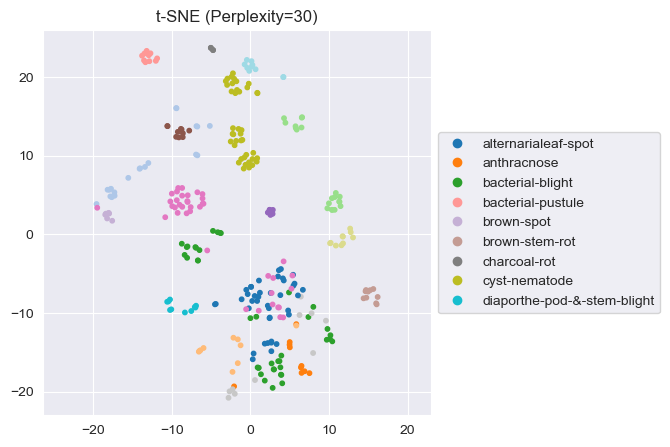

C:\Users\ursus\anaconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
C:\Users\ursus\AppData\Local\Temp\ipykernel_13292\3533901935.py:16: UserWarning: Mismatched number of handles and labels: len(handles) = 9 len(labels) = 18
  plt.legend(handles=scatter.legend_elements()[0], labels=y_labels, loc='center left', bbox_to_anchor=(1, 0.5))


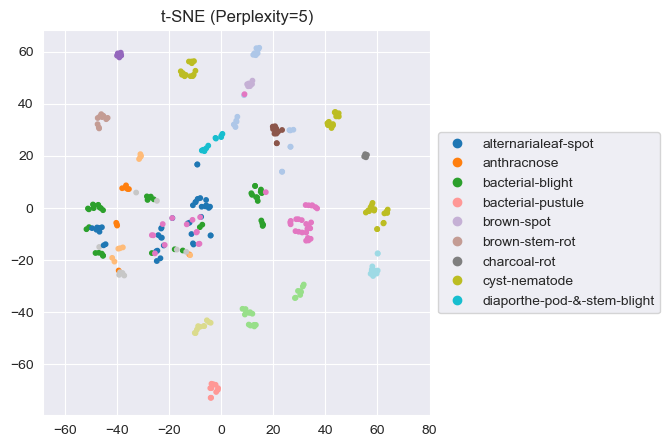

C:\Users\ursus\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\ursus\AppData\Local\Temp\ipykernel_13292\3533901935.py:16: UserWarning: Mismatched number of handles and labels: len(handles) = 9 len(labels) = 18
  plt.legend(handles=scatter.legend_elements()[0], labels=y_labels, loc='center left', bbox_to_anchor=(1, 0.5))


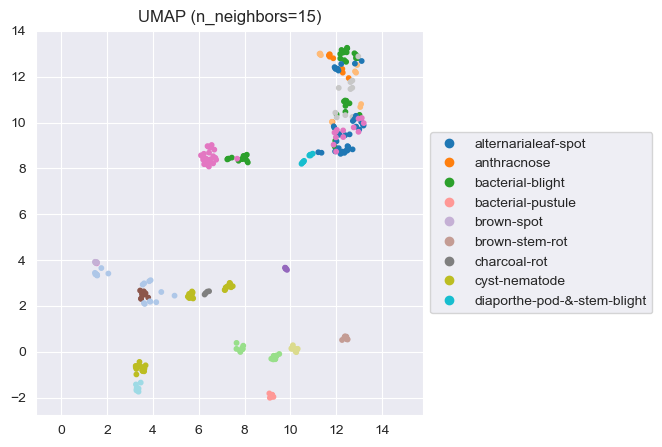

C:\Users\ursus\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\ursus\AppData\Local\Temp\ipykernel_13292\3533901935.py:16: UserWarning: Mismatched number of handles and labels: len(handles) = 9 len(labels) = 18
  plt.legend(handles=scatter.legend_elements()[0], labels=y_labels, loc='center left', bbox_to_anchor=(1, 0.5))


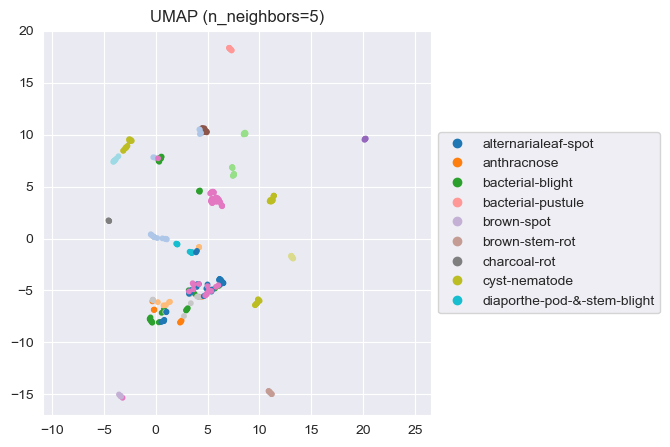

C:\Users\ursus\AppData\Local\Temp\ipykernel_13292\3533901935.py:16: UserWarning: Mismatched number of handles and labels: len(handles) = 9 len(labels) = 18
  plt.legend(handles=scatter.legend_elements()[0], labels=y_labels, loc='center left', bbox_to_anchor=(1, 0.5))


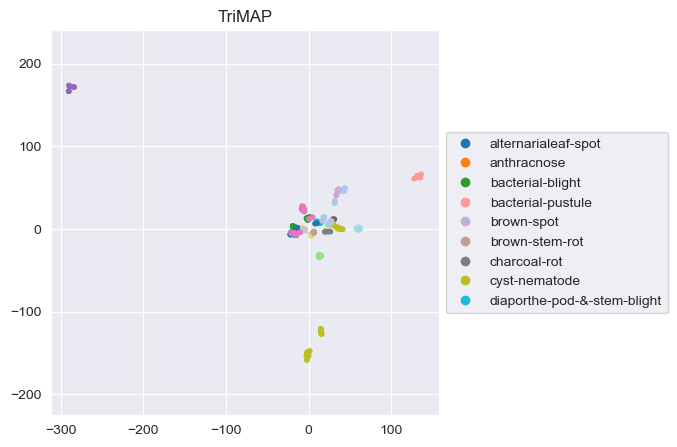

C:\Users\ursus\AppData\Local\Temp\ipykernel_13292\3533901935.py:16: UserWarning: Mismatched number of handles and labels: len(handles) = 9 len(labels) = 18
  plt.legend(handles=scatter.legend_elements()[0], labels=y_labels, loc='center left', bbox_to_anchor=(1, 0.5))


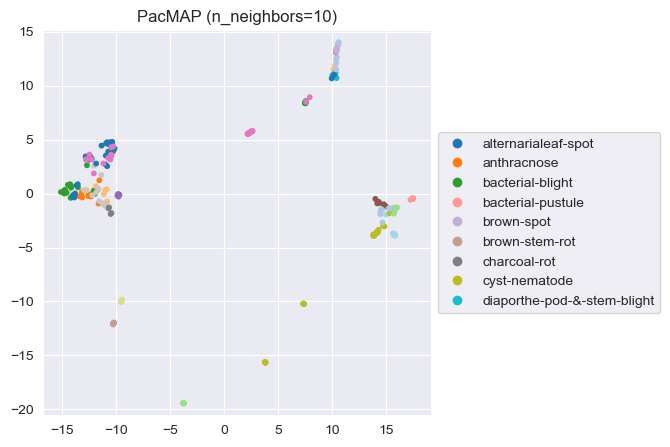

In [12]:
# Подготовка полных данных для визуализации
X_full_scaled = scaler.transform(X_imputed)

# --- ИСПРАВЛЕНИЕ ---
# Преобразуем numpy.ndarray в list
y_labels = list(le.classes_)
# --- КОНЕЦ ИСПРАВЛЕНИЯ ---


# Функция для отрисовки
def plot_embedding(embedding, y_numeric, title):
    plt.figure(figsize=(5, 5))
    scatter = plt.scatter(embedding[:, 0], embedding[:, 1], c=y_numeric, cmap='tab20', s=10)
    plt.title(title)
    # Теперь y_labels - это list, и ошибки не будет
    plt.legend(handles=scatter.legend_elements()[0], labels=y_labels, loc='center left', bbox_to_anchor=(1, 0.5))
    plt.gca().set_aspect('equal', 'datalim')
    plt.show()

# --- t-SNE ---
# Параметр 1: Perplexity=30
tsne_30 = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
embedding_tsne_30 = tsne_30.fit_transform(X_full_scaled)
plot_embedding(embedding_tsne_30, y_encoded, 't-SNE (Perplexity=30)')

# Параметр 2: Perplexity=5
tsne_5 = TSNE(n_components=2, perplexity=5, random_state=42, n_iter=1000)
embedding_tsne_5 = tsne_5.fit_transform(X_full_scaled)
plot_embedding(embedding_tsne_5, y_encoded, 't-SNE (Perplexity=5)')


# --- UMAP ---
umap_15 = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
embedding_umap_15 = umap_15.fit_transform(X_full_scaled)
plot_embedding(embedding_umap_15, y_encoded, 'UMAP (n_neighbors=15)')
umap_5 = umap.UMAP(n_neighbors=5, min_dist=0.1, random_state=42)
embedding_umap_5 = umap_5.fit_transform(X_full_scaled)
plot_embedding(embedding_umap_5, y_encoded, 'UMAP (n_neighbors=5)')

# --- TRIMAP ---
trimap_viz = trimap.TRIMAP(n_dims=2, n_random=42)
embedding_trimap = trimap_viz.fit_transform(X_full_scaled)
plot_embedding(embedding_trimap, y_encoded, 'TriMAP')


# --- PacMAP ---
pacmap_viz = pacmap.PaCMAP(n_components=2, n_neighbors=10, random_state=42)
embedding_pacmap = pacmap_viz.fit_transform(X_full_scaled)
plot_embedding(embedding_pacmap, y_encoded, 'PacMAP (n_neighbors=10)')

C:\Users\ursus\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\ursus\AppData\Local\Temp\ipykernel_13292\3533901935.py:16: UserWarning: Mismatched number of handles and labels: len(handles) = 9 len(labels) = 18
  plt.legend(handles=scatter.legend_elements()[0], labels=y_labels, loc='center left', bbox_to_anchor=(1, 0.5))


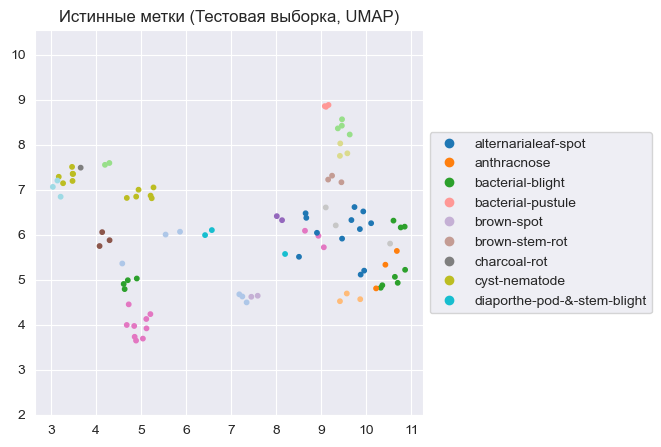

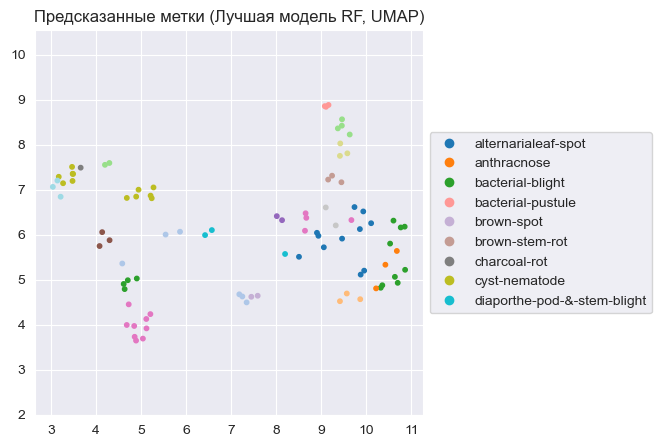

In [13]:
best_model = RandomForestClassifier(n_estimators=100, random_state=42)
best_model.fit(X_train_smote, y_train_smote)

y_pred_test = best_model.predict(X_test_scaled)

umap_test = umap.UMAP(n_neighbors=10, min_dist=0.1, random_state=42)
embedding_test = umap_test.fit_transform(X_test_scaled)

plot_embedding(embedding_test, y_test, 'Истинные метки (Тестовая выборка, UMAP)')

plot_embedding(embedding_test, y_pred_test, 'Предсказанные метки (Лучшая модель RF, UMAP)')